In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

In [2]:
#v = (h/e)*f-phi
#np.loadtxt('photoelectric.csv', delimiter=',', skiprows=1)
data= np.loadtxt('photoelectric.csv', delimiter=',', skiprows=1)
f = data[:,0]
V = data[:,1]
def linear_model(f, m, c):
    return m * f + c
popt, pcov = curve_fit(linear_model, f, V)
m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))   # uncertainties
#m, c = np.polyfit(f, V, 1)

e = 1.602e-19
h = m * e
print (f'Plancks constant: {h}')

phi = -c * e
#phi = (h/e)*f - V
print (f'Work function: {phi}') 

phi_volts = -c
print (f'Work function in volts: {phi_volts}')


print (f'Uncertainty of intercept: {c_err}')
print (f'Slope: {m}')
print (f'Intercept: {c}')
print (f'Uncertainty in Work function: {phi_volts} +/- {c_err} V')

# The metal plate is likely made of Nd 

Plancks constant: 6.351029983348348e-34
Work function: 3.1827290928041476e-19
Work function in volts: 1.9867222801524018
Uncertainty of intercept: 0.08445255813799026
Slope: 3.9644381918529015e-15
Intercept: -1.9867222801524018
Uncertainty in Work function: 1.9867222801524018 +/- 0.08445255813799026 V


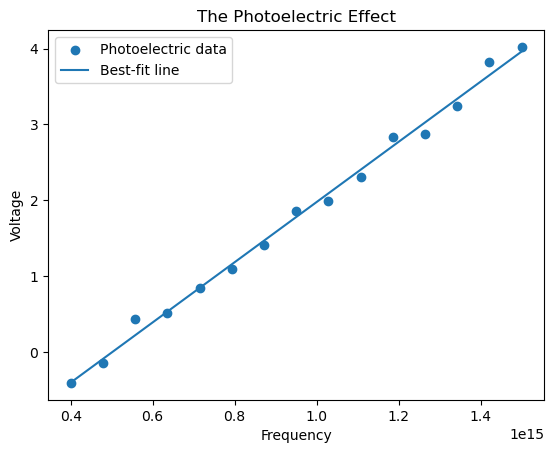

In [3]:
plt.scatter(f, V, label= 'Photoelectric data')
plt.plot(f, linear_model(f, m, c), label= 'Best-fit line')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Voltage (V)')
plt.title('The Photoelectric Effect')
plt.legend()
plt.show()

In [4]:
#np.loadtxt('decay_data.csv', delimiter= ',', skiprows= 1)
decay= np.loadtxt('decay_data.csv', delimiter= ',', skiprows= 1)

t= decay[:,0]
N= decay[:,1]

def decay_model (t, N0, lam, bg):
    return N0 * np.exp(-lam * t) + bg

#initial guesses
p0 = [900, 0.01, 20] # [N0, lam, bg]

popt, pcov = curve_fit(decay_model, t, N, p0=p0)


N0_fit, lam_fit, bg_fit = popt
N0_err, lam_err, bg_err = np.sqrt(np.diag(pcov))

print("N0 =", N0_fit, "+/-", N0_err) 
print("lambda =", lam_fit, "+/-", lam_err) 
print("background =", bg_fit, "+/-", bg_err)

t_half = np.log(2)/lam_fit
print('Half-life =', t_half)

N0 = 788.9420133097568 +/- 9.732071333714199
lambda = 0.09522555888637906 +/- 0.0024603771505862303
background = 23.4745898079236 +/- 3.9196942706331086
Half-life = 7.279003543439346


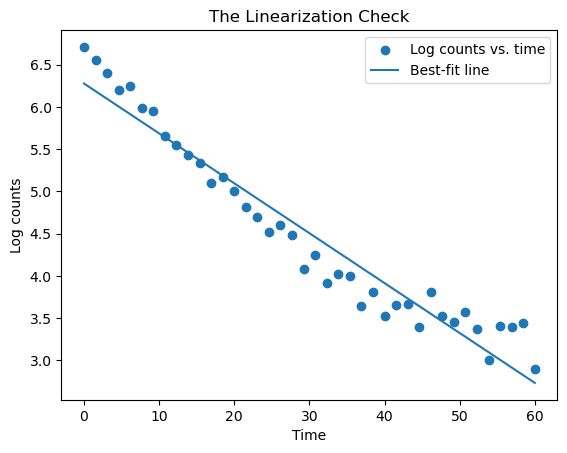

In [6]:
#log_counts = np.log(N)
log_counts = np.log(np.where(N > 0, N, np.nan))
lam_fit, bg_fit = np.polyfit(t, log_counts, 1)


plt.scatter(t, log_counts, label= 'Log counts vs. time')
plt.plot(t, linear_model(t, lam_fit, bg_fit), label= 'Best-fit line')
plt.xlabel('Time (s)')
plt.ylabel('Log counts')
plt.title('The Linearization Check')
plt.legend()
plt.show()

# The best fit lines for both Method A & B are relatively aligned with the data plots. The majority of the data points on B are below the fit line. Therefore, Method A has a more accurate fit line than method B
# The log count data is linear. The data points begin deviating from the best fit line at 20s. Changing the slope of the best fit line may improve its accuracy.

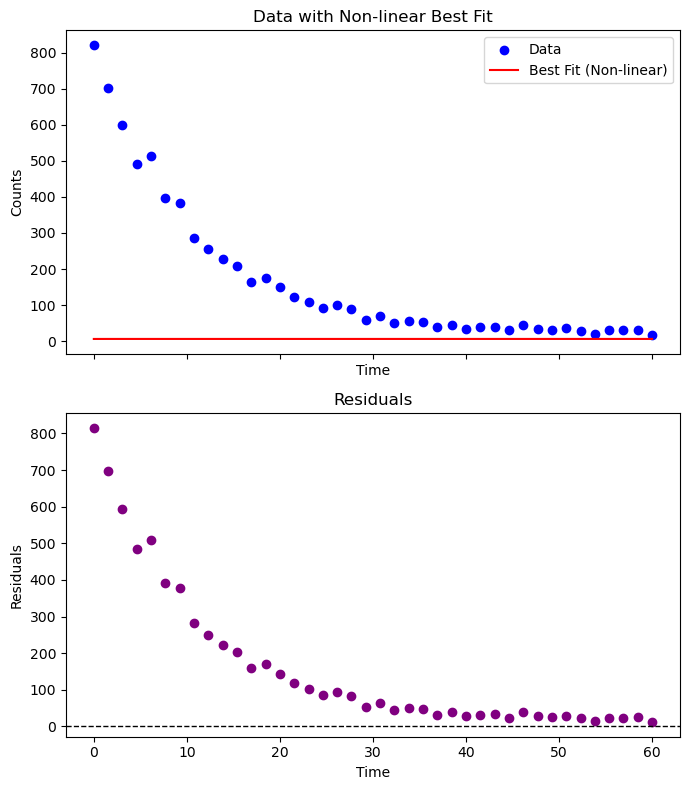

In [9]:
N_model = decay_model(t, lam_fit, N0_fit, bg_fit) 

residuals = N - N_model 

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 8)) 

ax1.scatter(t, N, label='Data', color='blue') 
ax1.plot(t, N_model, label='Best Fit ', color='red') 
ax1.set_ylabel('Counts') 
ax1.set_xlabel('Time (s)')
ax1.set_title('Data with Non-linear Best Fit')
ax1.legend() 

ax2.scatter(t, residuals, color='purple') 
ax2.axhline(0, color='black', linestyle='--', linewidth=1) 
ax2.set_xlabel('Time (s)') 
ax2.set_ylabel('Residuals') 
ax2.set_title('Residuals') 
plt.tight_layout() 
plt.show()

# The residuals have a U-like shape. I am not confident that this is correct.

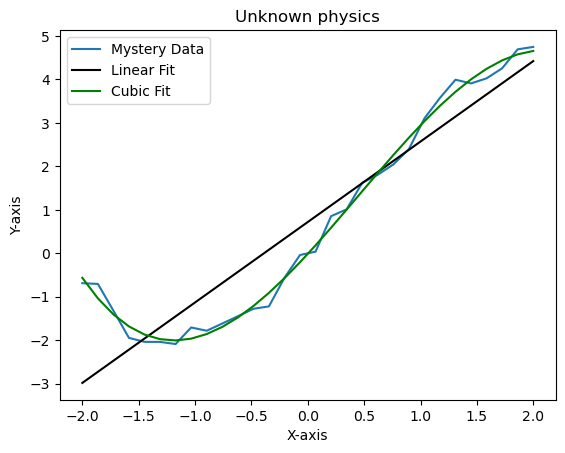

In [12]:
mystery = np.loadtxt('mystery_data.csv', delimiter= ',', skiprows= 1)

x = mystery[:,0]
y = mystery[:,1]

def poly1(x, a, b):
    return a * x + b

def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

popt1, pcov1 = curve_fit(poly1, x, y)
a1, b1 = popt1

popt3, pcov3 = curve_fit(poly3, x, y)
a3, b3, c3, d3 = popt3

y_lin = poly1(x, a1, b1)
y_cub = poly3(x, a3, b3, c3, d3)

plt.plot(x, y, label= 'Mystery Data')
plt.plot(x, y_lin, label= 'Linear Fit', color= 'black')
plt.plot(x, y_cub, label= 'Cubic Fit', color= 'green')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Unknown physics')
plt.legend()
plt.show()

# I believe 4 terms work best to capture the mystery data.

In [ ]:
f = data[:,0]   # frequency (Hz)
V = data[:,1]   # stopping potential (V)

def linear_model(f, m, c):
    return m * f + c

# --- Linear fit using polyfit ---
m, c = np.polyfit(f, V, 1)

e = 1.602e-19
h = m * e
phi = -c * e   # correct work function

print(f"Planck's constant (polyfit): {h}")
print(f"Work function (J): {phi}")

# --- Fit using curve_fit ---
popt, pcov = curve_fit(linear_model, f, V)
m_cf, c_cf = popt
m_err, c_err = np.sqrt(np.diag(pcov))

print(f"Slope (curve_fit): {m_cf}")
print(f"Intercept (curve_fit): {c_cf:.3f}")
print(f"Uncertainty of intercept: {c_err:.3f}")
